# FlameIQ Refill Prediction — Model Experiments

## Objective

This notebook documents the machine-learning experiments conducted for the FlameIQ refill prediction proof of concept.

Two prediction pathways are evaluated:

1. **Cold-start prediction** - for new users with no previous refill history.
2. **Personalised prediction** - for returning users with historical refill-cycle information.

Each pathway is compared against a transparent baseline before selecting a machine-learning model.

All performance figures in this notebook are based on labelled synthetic proof-of-concept data and should not be interpreted as production accuracy.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
BASE_DIR = Path.cwd().resolve()

if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

REPORTS_DIR = BASE_DIR / "reports"

comparison = pd.read_csv(
    REPORTS_DIR / "model_comparison.csv"
)

cold_predictions = pd.read_csv(
    REPORTS_DIR / "cold_start_test_predictions.csv"
)

personalised_predictions = pd.read_csv(
    REPORTS_DIR / "personalised_test_predictions.csv"
)

comparison

,Pathway,Model,MAE_days,RMSE_days,R2,Within_2_days_pct,Within_5_days_pct,Late_prediction_pct
0,Cold Start,Lasso,4.575,6.021,0.748,31.75,65.08,54.76
1,Cold Start,Elastic Net,4.613,6.086,0.742,30.16,64.68,55.56
2,Cold Start,Linear Regression,4.637,6.064,0.744,29.76,63.10,53.97
3,Cold Start,Gradient Boosting,4.687,5.978,0.751,27.38,64.29,52.78
4,Cold Start,Random Forest,5.156,6.623,0.695,22.62,55.16,51.59
5,Cold Start,Baseline,7.520,9.785,0.333,23.02,45.63,44.84
6,Personalised,Gradient Boosting,3.320,4.461,0.858,42.62,77.48,55.44
7,Personalised,Random Forest,3.392,4.596,0.850,42.07,77.06,56.41
8,Personalised,Linear Regression,3.447,4.540,0.853,38.88,76.85,54.95
9,Personalised,Lasso,3.448,4.558,0.852,39.02,76.92,54.89


## Experimental Design

The prediction problem is formulated as a regression task.

The target variable is:

`actual_cycle_days`

This represents the total duration of a household LPG refill cycle.

To reduce information leakage, train/test splitting was performed by `user_id`, meaning the same household was not intentionally placed in both training and test groups.

Five regression algorithms were compared:

- Linear Regression
- Lasso Regression
- Elastic Net
- Random Forest Regressor
- Gradient Boosting Regressor

Each pathway was also compared against a simple baseline.

In [3]:
cold_results = (
    comparison[
        comparison["Pathway"] == "Cold Start"
    ]
    .sort_values("MAE_days")
    .reset_index(drop=True)
)

cold_results

,Pathway,Model,MAE_days,RMSE_days,R2,Within_2_days_pct,Within_5_days_pct,Late_prediction_pct
0,Cold Start,Lasso,4.575,6.021,0.748,31.75,65.08,54.76
1,Cold Start,Elastic Net,4.613,6.086,0.742,30.16,64.68,55.56
2,Cold Start,Linear Regression,4.637,6.064,0.744,29.76,63.10,53.97
3,Cold Start,Gradient Boosting,4.687,5.978,0.751,27.38,64.29,52.78
4,Cold Start,Random Forest,5.156,6.623,0.695,22.62,55.16,51.59
5,Cold Start,Baseline,7.520,9.785,0.333,23.02,45.63,44.84


In [4]:
personalised_results = (
    comparison[
        comparison["Pathway"] == "Personalised"
    ]
    .sort_values("MAE_days")
    .reset_index(drop=True)
)

personalised_results

,Pathway,Model,MAE_days,RMSE_days,R2,Within_2_days_pct,Within_5_days_pct,Late_prediction_pct
0,Personalised,Gradient Boosting,3.320,4.461,0.858,42.62,77.48,55.44
1,Personalised,Random Forest,3.392,4.596,0.850,42.07,77.06,56.41
2,Personalised,Linear Regression,3.447,4.540,0.853,38.88,76.85,54.95
3,Personalised,Lasso,3.448,4.558,0.852,39.02,76.92,54.89
4,Personalised,Elastic Net,3.563,4.726,0.841,38.05,75.47,55.02
5,Personalised,Baseline,5.251,7.169,0.635,31.39,62.58,46.99


In [5]:
cold_baseline_mae = cold_results.loc[
    cold_results["Model"] == "Baseline",
    "MAE_days"
].iloc[0]

cold_best_mae = cold_results.loc[
    cold_results["Model"] == "Lasso",
    "MAE_days"
].iloc[0]

cold_improvement = (
    (cold_baseline_mae - cold_best_mae)
    / cold_baseline_mae
) * 100


personal_baseline_mae = personalised_results.loc[
    personalised_results["Model"] == "Baseline",
    "MAE_days"
].iloc[0]

personal_best_mae = personalised_results.loc[
    personalised_results["Model"] == "Gradient Boosting",
    "MAE_days"
].iloc[0]

personal_improvement = (
    (personal_baseline_mae - personal_best_mae)
    / personal_baseline_mae
) * 100


print(
    f"Cold-start improvement over baseline: "
    f"{cold_improvement:.1f}%"
)

print(
    f"Personalised improvement over baseline: "
    f"{personal_improvement:.1f}%"
)

Cold-start improvement over baseline: 39.2%
Personalised improvement over baseline: 36.8%


## Cold-Start Model Results

The cold-start baseline produced an MAE of approximately 7.52 days.

Lasso Regression reduced this to approximately 4.58 days, representing an improvement of about 39%.

The cold-start model also placed approximately 65% of test predictions within ±5 days of the generated refill-cycle duration.

Lasso was selected because it produced the lowest MAE among the evaluated cold-start models while remaining relatively simple and interpretable.

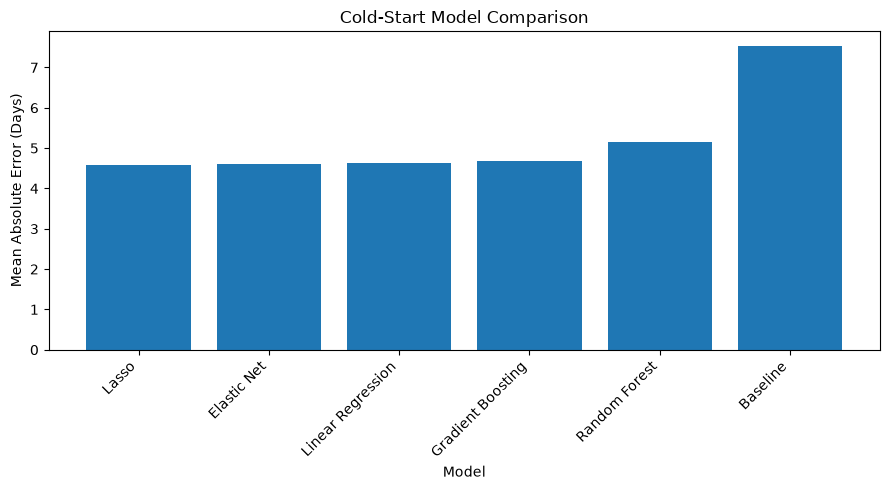

In [6]:
plt.figure(figsize=(9, 5))

plt.bar(
    cold_results["Model"],
    cold_results["MAE_days"]
)

plt.title("Cold-Start Model Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (Days)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

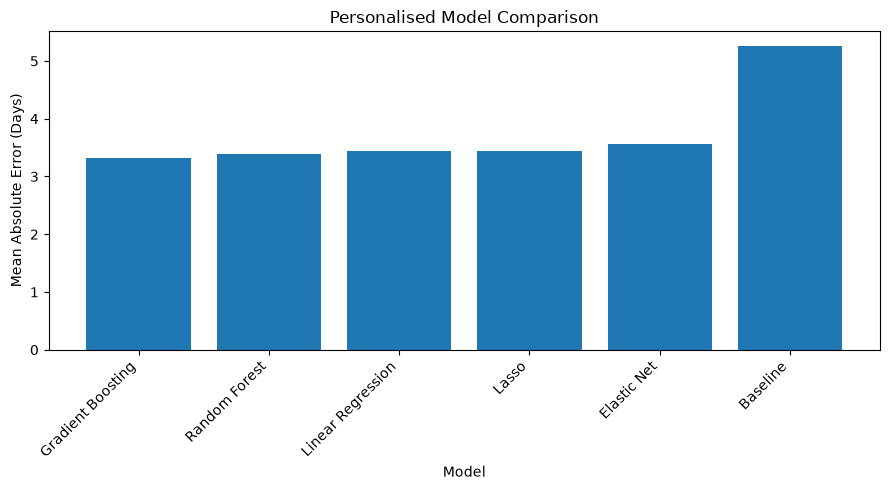

In [7]:
plt.figure(figsize=(9, 5))

plt.bar(
    personalised_results["Model"],
    personalised_results["MAE_days"]
)

plt.title("Personalised Model Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (Days)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Personalised Model Results

The personalised baseline produced an MAE of approximately 5.25 days.

Gradient Boosting reduced this to approximately 3.32 days, representing an improvement of about 37%.

Approximately 77.5% of personalised predictions fell within ±5 days of the generated refill-cycle duration.

Gradient Boosting was selected because it produced the lowest MAE and highest R² among the evaluated personalised models.

In [8]:
selected_models = pd.DataFrame(
    {
        "Pathway": [
            "Cold Start",
            "Personalised"
        ],
        "Selected Model": [
            "Lasso",
            "Gradient Boosting"
        ],
        "MAE_days": [
            cold_best_mae,
            personal_best_mae
        ]
    }
)

selected_models

,Pathway,Selected Model,MAE_days
0,Cold Start,Lasso,4.575
1,Personalised,Gradient Boosting,3.320


In [9]:
personalisation_gain = (
    (cold_best_mae - personal_best_mae)
    / cold_best_mae
) * 100

print(
    f"MAE reduction from cold-start to personalised: "
    f"{personalisation_gain:.1f}%"
)

MAE reduction from cold-start to personalised: 27.4%


## Value of Personalisation

The cold-start model achieves an MAE of approximately 4.58 days.

Once refill history becomes available, the personalised Gradient Boosting model reduces MAE to approximately 3.32 days.

This represents an additional reduction in prediction error of roughly 27%.

The result supports FlameIQ's proposed prediction architecture:

- Initial estimates use household and cooking behaviour.
- Predictions become more personalised as refill history accumulates.

In [10]:
cold_predictions.head()

,user_id,refill_cycle_id,actual_cycle_days,predicted_cycle_days,absolute_error_days
0,USR_20013,USR_20013_C01,27,36.64,9.64
1,USR_20026,USR_20026_C01,26,24.52,1.48
2,USR_20032,USR_20032_C01,18,18.02,0.02
3,USR_20036,USR_20036_C01,23,30.29,7.29
4,USR_20037,USR_20037_C01,30,39.54,9.54


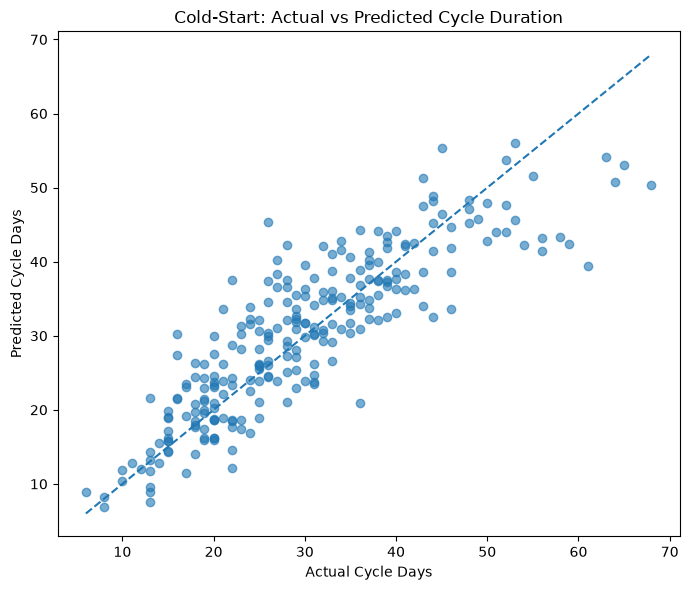

In [11]:
plt.figure(figsize=(7, 6))

plt.scatter(
    cold_predictions["actual_cycle_days"],
    cold_predictions["predicted_cycle_days"],
    alpha=0.6
)

minimum = min(
    cold_predictions["actual_cycle_days"].min(),
    cold_predictions["predicted_cycle_days"].min()
)

maximum = max(
    cold_predictions["actual_cycle_days"].max(),
    cold_predictions["predicted_cycle_days"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title("Cold-Start: Actual vs Predicted Cycle Duration")
plt.xlabel("Actual Cycle Days")
plt.ylabel("Predicted Cycle Days")
plt.tight_layout()
plt.show()

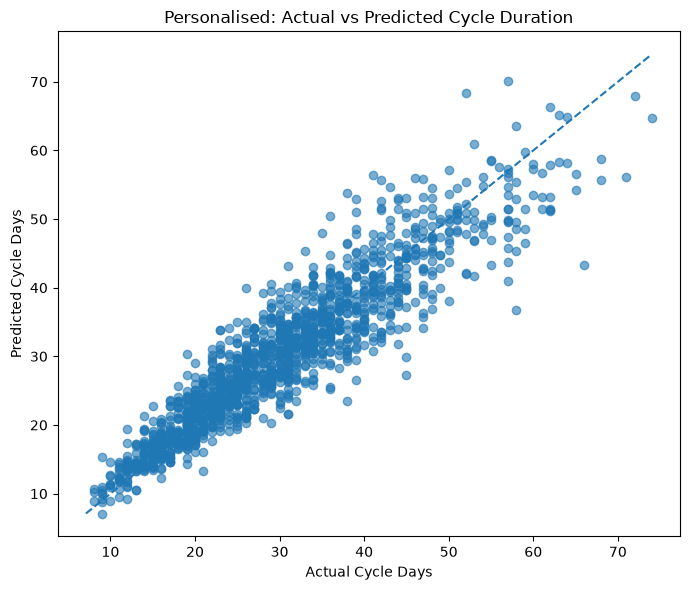

In [12]:
plt.figure(figsize=(7, 6))

plt.scatter(
    personalised_predictions["actual_cycle_days"],
    personalised_predictions["predicted_cycle_days"],
    alpha=0.6
)

minimum = min(
    personalised_predictions["actual_cycle_days"].min(),
    personalised_predictions["predicted_cycle_days"].min()
)

maximum = max(
    personalised_predictions["actual_cycle_days"].max(),
    personalised_predictions["predicted_cycle_days"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title(
    "Personalised: Actual vs Predicted Cycle Duration"
)

plt.xlabel("Actual Cycle Days")
plt.ylabel("Predicted Cycle Days")
plt.tight_layout()
plt.show()